In [1]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [2]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA')
from ESMCBA.imports import *
from ESMCBA import graph_utils

In [3]:
epitopes_eval = ['A3101',
 'B5701',
 'B1801',
 'A1101',
 'B4403',
 'B5101',
 'A2601',
 'B1501',
 'A3001',
 'A0205',
 'B3801',
 'A6801',
 'A0101',
 'B0702',
 'A0301',
 'A0201',
 'B4402',
 'B0801',
 'B3906',
 'B1402',
 'A2402',
 'B4001',
 'A3201',
 'B3501',
 'C0701']

In [4]:
epitopes_eval = ['A0101','A0207','A1102','A2602','A3201','A6812','B1402','B1542','B2706','B3801','B4013','B5101','B7301','C0701',
'A0201','A0211','A2301','A2603','A3207','A6901','B1501','B1801','B2709','B3901','B4201','B5201','B8301','C0702',
'A0202','A0216','A2402','A2902','A3301','A8001','B1502','B2701','B2720','B3906','B4402','B5301','C0303','C0802',
'A0204','A0217','A2403','A3001','A6601','B0702','B1503','B2702','B3503','B3909','B4501','B5401','C0401','C1203',
'A0205','A0301','A2501','A3002','A6801','B0801','B1509','B2703','B3508','B4001','B4601','B5701','C0501','C1402',
'A0206','A1101','A2601','A3101','A6802','B0802','B1510','B2704','B3701','B4002','B4801','B5801','C0602','C1502']

In [5]:
import glob
import os
import pandas as pd
import numpy as np
from collections import defaultdict

# Initialize data structures
rows = []
ic50_by_hla = defaultdict(list)
ic50_by_hla_type = defaultdict(list)
source_by_hla_type = defaultdict(list)

for file in glob.glob("/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA*_final.csv"):
    # Skip files with 'HLAHLA' or 'HLAD' in name
    if 'HLAHLA' in file or 'HLAD' in file:
        continue
    
    # Skip if file doesn't exist or is empty
    if not os.path.exists(file) or os.path.getsize(file) == 0:
        continue
    
    # Read CSV
    df = pd.read_csv(file, sep=',', header=None)
    # df = df.drop_duplicates(0)
    if df.empty:
        continue
    
    # Extract HLA info from filename
    hla = 'HLA' + os.path.basename(file).split('HLA')[-1].split('_final')[0]
    hla_type = hla[3]
    
    # Count unique sequences in first column
    epitope_count = df[0].nunique()
    
    # Collect IC50 values if column 7 exists
    if 7 in df.columns:
        ic50_values = df[7].tolist()
        # ic50_values = [x for x in ic50_values if int(x) < 10_000 else]
        source = df[6].tolist()
        ic50_by_hla[hla].extend(ic50_values)
        ic50_by_hla_type[hla_type].extend(ic50_values)
        source_by_hla_type[hla_type].extend(source)
    
    # Process sequences for train/eval split
    df.columns = ['sequence','ref_ID','submissionID','Epitope_ID','protein_origin',
                  'ID_SOURCE','SOURCE_ORGANISM','IC50_nM','DESCRIPTION_BINDING','Year_submission']
    
    df['Year_submission'] = pd.to_numeric(df['Year_submission'], errors='coerce')
    df = df.fillna(0)
    df = df[df['Year_submission'].notna()]
    
    seq = df['sequence'].astype(str).str.strip().str.upper()
    train_seq = set(seq[~(df['Year_submission'] > 2019)].unique())
    eval_seq = set(seq[df['Year_submission'] > 2019].unique())
    overlap = train_seq.intersection(eval_seq)
    
    rows.append({
        'HLA': hla,
        'n_train_epitopes': len(train_seq),
        'n_eval_epitopes': len(eval_seq),
        'n_overlaps_in_BA': len(overlap),
        'Epitope Count': epitope_count
    })

# Create final DataFrame
hla_counts = pd.DataFrame(rows).sort_values('HLA').reset_index(drop=True)
hla_counts['hla_type'] = hla_counts['HLA'].str[3]
hla_counts = hla_counts[hla_counts['hla_type'] != 'E']
hla_counts = hla_counts.sort_values(by='n_overlaps_in_BA',ascending = False)

In [6]:
hla_counts.to_csv('../../data/summary_BA_dataset.csv', index =None)

In [7]:
df

,sequence,ref_ID,submissionID,Epitope_ID,protein_origin,ID_SOURCE,SOURCE_ORGANISM,IC50_nM,DESCRIPTION_BINDING,Year_submission
0,NLLVQYGAKI,44801,28769,AAO89309.1,ankyrin-like protein,10254,Vaccinia virus WR (Vaccinia virus (strain WR)),1320.0,Positive-Low,0.0
1,DIIDLLLPST,8660,28777,AAO89309.1,ankyrin-like protein,10254,Vaccinia virus WR (Vaccinia virus (strain WR)),6590.0,Negative,0.0
2,ETMYLTMKAI,14490,28795,AAO89309.1,ankyrin-like protein,10254,Vaccinia virus WR (Vaccinia virus (strain WR)),25.2,Positive-High,0.0
3,IICEDAMYYA,26446,28788,AAO89309.1,ankyrin-like protein,10254,Vaccinia virus WR (Vaccinia virus (strain WR)),108.0,Positive-Intermediate,0.0
4,EVIERINLL,14724,26840,AAO89309.1,ankyrin-like protein,10254,Vaccinia virus WR (Vaccinia virus (strain WR)),292.0,Positive-Intermediate,0.0
...,...,...,...,...,...,...,...,...,...,...
6468,SIQLDEKSSI,58674,42883,P16714.2,\N,\N,\N,131.0,Positive-Intermediate,0.0
6469,QVKDNIISRT,52722,32156,P16714.2,\N,\N,\N,421.0,Positive-Intermediate,0.0
6470,DQLVFNSISA,9875,27145,P16714.2,\N,\N,\N,289.0,Positive-Intermediate,0.0
6471,AMHDKKIDIL,3101,26723,AAO89380.1,\N,\N,\N,1180.0,Positive-Low,0.0


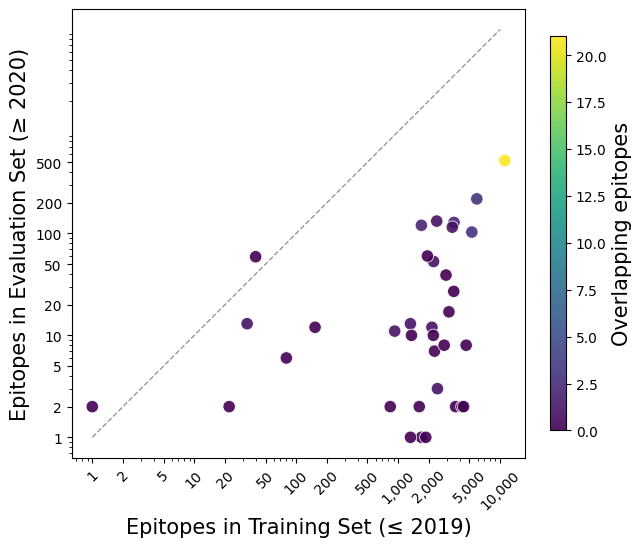

In [8]:
from matplotlib.colors import Normalize

df = hla_counts[(hla_counts['n_train_epitopes'] > 0) & (hla_counts['n_eval_epitopes'] > 0)].copy()

fig, ax = plt.subplots(figsize=(6.5, 6.5))

sns.scatterplot(
    data=df,
    x='n_train_epitopes', y='n_eval_epitopes',
    hue='n_overlaps_in_BA', palette='viridis', hue_norm=(df['n_overlaps_in_BA'].min(), df['n_overlaps_in_BA'].max()), s=80, edgecolor='white', linewidth=0.6,
    alpha=0.9, ax=ax, legend=False
)
ax.set_xscale('log')
ax.set_yscale('log')

# 3) nice log ticks with real-number labels
def nice_log_ticks(vmin, vmax):
    vmin = max(vmin, 1)
    dmin = int(np.floor(np.log10(vmin)))
    dmax = int(np.ceil(np.log10(max(vmax, vmin))))
    ticks = []
    for d in range(dmin, dmax + 1):
        for m in (1, 2, 5):
            val = m * (10 ** d)
            if vmin <= val <= vmax:
                ticks.append(val)
    return np.unique(ticks)

xmin, xmax = df['n_train_epitopes'].min(), df['n_train_epitopes'].max()
ymin, ymax = df['n_eval_epitopes'].min(),  df['n_eval_epitopes'].max()

xticks = nice_log_ticks(xmin, xmax)
yticks = nice_log_ticks(ymin, ymax)

ax.set_xticks(xticks)
ax.set_yticks(yticks)
ax.set_xticklabels([f"{int(t):,}" for t in xticks], rotation= 45, fontsize =10)
ax.set_yticklabels([f"{int(t):,}" for t in yticks], fontsize =10)

# 4) diagonal reference line (y = x)
lo = min(xticks[0], yticks[0])
hi = max(xticks[-1], yticks[-1])
ax.plot([lo, hi], [lo, hi], linestyle='--', linewidth=1, color='gray', alpha=0.8)

ax.collections[0].set_norm(Normalize(vmin=df['n_overlaps_in_BA'].min(), vmax=df['n_overlaps_in_BA'].max()))

import matplotlib.cm as cm

mappable = ax.collections[0]
cbar = plt.colorbar(mappable, ax=ax, pad=0.05, fraction=0.035, shrink=0.7, aspect=25, cmap='viridis')
cbar.set_label('Overlapping epitopes', fontsize=15)

# 6) labels and cosmetics
ax.set_xlabel('Epitopes in Training Set (≤ 2019)', fontsize =15)
ax.set_ylabel('Epitopes in Evaluation Set (≥ 2020)', fontsize =15)
ax.set_aspect('equal', 'box')
ax.grid(False)
plt.savefig('../../figures_manuscript/1a_supp_overlap.pdf')
plt.tight_layout()


In [9]:
df.to_csv('../../data/table_summary_BA_data.csv', index= None)

In [10]:
plot_data = pd.read_csv('../../data/01_predictions_models.csv')

In [11]:
IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/IEDB_subseted_HLA_w_BA_full_for_training.csv.gz')

/tmp/ipykernel_3649513/3353852296.py:1: DtypeWarning: Columns (6,12,13,14,27,28,29,30,34,35,36,37,38,39,40,41,42,45,46,47,48,49,50,51,52,53,54,55,56,57,65,66,67,68,72,73,74,75,76,79,80,81,82,83,84,85,86,87,88,89,92,95,100,101,102,103,104,105,106,109,110) have mixed types. Specify dtype option on import or set low_memory=False.
  IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/IEDB_subseted_HLA_w_BA_full_for_training.csv.gz')


In [12]:

epitopes_IEDB = np.array(["HLA"+ x for x in  epitopes_eval])
epitopes_IEDB
IEDB_full_subset = IEDB_full[IEDB_full['MHC Restriction - Name'].isin(epitopes_IEDB)]
IEDB_full_subset = IEDB_full_subset[IEDB_full_subset['Assay - Qualitative Measurement'].str.contains('Positive')]

peptides = IEDB_full_subset['Epitope - Name'].unique()
# set max columns
pd.set_option('display.max_columns', None)


In [13]:
# plot_df.sort_values(by='x_iedb_count',ascending = False)

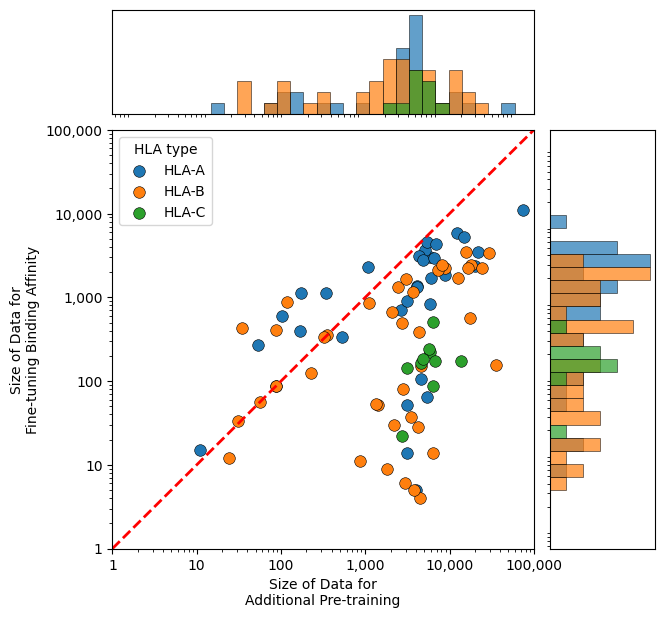

In [14]:
from matplotlib.gridspec import GridSpec


x_counts = (
    IEDB_full_subset
    .drop_duplicates(['Epitope - Name', 'MHC Restriction - Name'])
    .groupby('MHC Restriction - Name')
    .size()
    .rename('x_iedb_count')
    .reset_index()
    .rename(columns={'MHC Restriction - Name': 'HLA'})
)
y_counts = hla_counts[['HLA', 'n_train_epitopes']].rename(columns={'n_train_epitopes': 'y_ba_count'})
plot_df = pd.merge(x_counts, y_counts, on='HLA', how='inner')
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['x_iedb_count', 'y_ba_count'])
plot_df = plot_df[(plot_df['x_iedb_count'] > 0) & (plot_df['y_ba_count'] > 0)].copy()
plot_df['locus'] = plot_df['HLA'].str.extract(r'(?i)HLA[-_\s]*([ABC])', expand=False).str.upper().fillna('Other')
color_map = {'A': '#1f77b4', 'B': '#ff7f0e', 'C': '#2ca02c', 'Other': '#7f7f7f'}
present = [l for l in ['A', 'B', 'C'] if not plot_df[plot_df['locus'] == l].empty]

fig = plt.figure(figsize=(7, 7))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], wspace=0.06, hspace=0.06)
ax_scatter = fig.add_subplot(gs[1, 0])
ax_hist_x = fig.add_subplot(gs[0, 0])
ax_hist_y = fig.add_subplot(gs[1, 1])

for locus in present:
    df_loc = plot_df[plot_df['locus'] == locus]
    ax_scatter.scatter(
        df_loc['x_iedb_count'],
        df_loc['y_ba_count'],
        s=70,
        label=f'HLA-{locus}',
        color=color_map[locus],
        edgecolors='k',
        linewidths=0.4,
    )

ax_scatter.set_xscale('log')
ax_scatter.set_yscale('log')
ax_scatter.set_xlim(1, 100000)
ax_scatter.set_ylim(1, 100000)
ax_scatter.plot([1, 100000], [1, 100000], 'r--', lw=2)

# Set custom tick locations and labels
tick_values = [1, 10, 100, 1000, 10000, 100000]
tick_labels = ['1', '10', '100', '1,000', '10,000', '100,000']
ax_scatter.set_xticks(tick_values)
ax_scatter.set_xticklabels(tick_labels)
ax_scatter.set_yticks(tick_values)
ax_scatter.set_yticklabels(tick_labels)

x_bins = np.logspace(0, 5, 30)
y_bins = np.logspace(0, 5, 30)

for locus in present:
    df_loc = plot_df[plot_df['locus'] == locus]
    ax_hist_x.hist(df_loc['x_iedb_count'], bins=x_bins, color=color_map[locus], 
                   alpha=0.7, edgecolor='k', linewidth=0.5)
    ax_hist_y.hist(df_loc['y_ba_count'], bins=y_bins, color=color_map[locus], 
                   alpha=0.7, edgecolor='k', linewidth=0.5, orientation='horizontal')

ax_hist_x.set_xscale('log')
ax_hist_y.set_yscale('log')
ax_hist_x.set_xticks([])
ax_hist_x.set_yticks([])
ax_hist_y.set_xticks([])
ax_hist_y.set_yticks([])

ax_scatter.set_xlabel('Size of Data for\nAdditional Pre-training')
ax_scatter.set_ylabel('Size of Data for\nFine-tuning Binding Affinity')
ax_scatter.legend(title='HLA type', frameon=True)
# plt.tight_layout()
plt.savefig('../../figures_manuscript/1a_training_data_plot.pdf', bbox_inches='tight')
plt.show()


/tmp/ipykernel_3649513/2905698194.py:190: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(


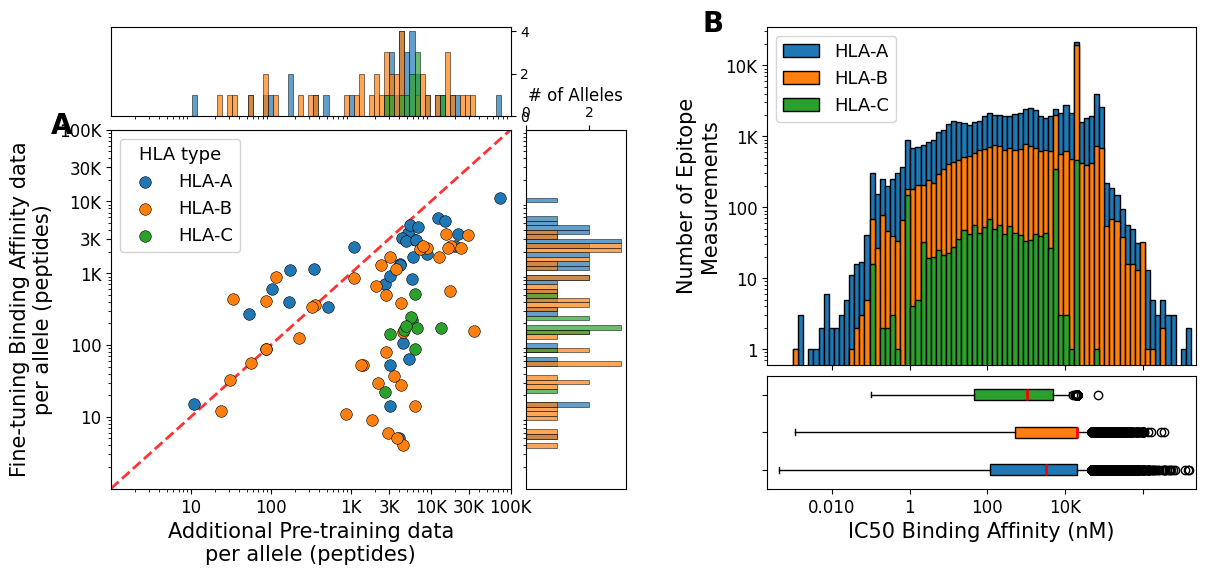

In [15]:
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter
from scipy.stats import spearmanr
import matplotlib.patches as mpatches

# ============================================================================
# PREPARE DATA FOR BOTH PLOTS
# ============================================================================

# Data for Plot A (scatter + marginals)
x_counts = (
    IEDB_full_subset
    .drop_duplicates(['Epitope - Name', 'MHC Restriction - Name'])
    .groupby('MHC Restriction - Name')
    .size()
    .rename('x_iedb_count')
    .reset_index()
    .rename(columns={'MHC Restriction - Name': 'HLA'})
)
y_counts = hla_counts[['HLA', 'n_train_epitopes']].rename(columns={'n_train_epitopes': 'y_ba_count'})
plot_df = pd.merge(x_counts, y_counts, on='HLA', how='inner')
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['x_iedb_count', 'y_ba_count'])
plot_df = plot_df[(plot_df['x_iedb_count'] > 0) & (plot_df['y_ba_count'] > 0)].copy()
plot_df['locus'] = plot_df['HLA'].str.extract(r'(?i)HLA[-_\s]*([ABC])', expand=False).str.upper().fillna('Other')

color_map_scatter = {'A': '#1f77b4', 'B': '#ff7f0e', 'C': '#2ca02c', 'Other': '#7f7f7f'}
present = [l for l in ['A', 'B', 'C'] if not plot_df[plot_df['locus'] == l].empty]

# Data for Plot B (IC50 histogram + boxplot)
color_map_ic50 = {
    'C': 'C2',
    'B': 'C1',
    'A': 'C0',
}
cleaned_ic50_by_type = {}
all_ic50_values = []
for hla_type, values in ic50_by_hla_type.items():
    if hla_type in color_map_ic50:
        cleaned = [float(v) for v in values if pd.notnull(v) and v != '\\N']
        cleaned_ic50_by_type[hla_type] = cleaned
        all_ic50_values.extend(cleaned)

bins = np.logspace(-3, 10, 100)

# Custom formatters
def format_ic50(x, pos):
    if x < 1:
        return f'{x:.3f}'
    elif x < 1000:
        return f'{int(x)}'
    elif x < 1_000_000:
        return f'{int(x/1000)}K'
    # else:
    #     return f'{int(x/1_000_000)}M'

def format_counts(y, pos):
    if y < 1000:
        return f'{int(y)}'
    elif y < 1_000_000:
        return f'{int(y/1000)}K'
    # else:
    #     return f'{int(y/1_000_000)}M'

# ============================================================================
# CREATE COMBINED FIGURE
# ============================================================================

fig = plt.figure(figsize=(14, 6))

# Create main grid: 1 row, 2 columns for A and B
main_gs = GridSpec(1, 2, figure=fig, width_ratios=[1.2, 1], wspace=0.3)

# ============================================================================
# PANEL A: Scatter plot with marginals (LEFT)
# ============================================================================

# Create nested GridSpec for scatter + marginals
gs_A = main_gs[0].subgridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], 
                               wspace=0.06, hspace=0.06)

ax_scatter = fig.add_subplot(gs_A[1, 0])
ax_hist_x = fig.add_subplot(gs_A[0, 0])
ax_hist_y = fig.add_subplot(gs_A[1, 1])

# Plot scatter points
for locus in present:
    df_loc = plot_df[plot_df['locus'] == locus]
    ax_scatter.scatter(
        df_loc['x_iedb_count'],
        df_loc['y_ba_count'],
        s=70,
        label=f'HLA-{locus}',
        color=color_map_scatter[locus],
        edgecolors='k',
        linewidths=0.4,
        zorder=3
    )

ax_scatter.set_xscale('log')
ax_scatter.set_yscale('log')
ax_scatter.set_xlim(1, 100000)
ax_scatter.set_ylim(1, 100000)

# Plot diagonal
diagonal_line = ax_scatter.plot([1, 100000], [1, 100000], 'r--', lw=2, zorder=2, alpha=0.8)[0]

# Set ticks
tick_values = [10, 100, 1000, 3000,  10000, 30000, 100000]
tick_labels = ['10', '100', '1K', '3K', '10K', '30K', '100K']
ax_scatter.set_xticks(tick_values)
ax_scatter.set_xticklabels(tick_labels, fontsize=12)
ax_scatter.set_yticks(tick_values)
ax_scatter.set_yticklabels(tick_labels, fontsize=12)

# Histograms
x_bins = np.logspace(0, 5, 80)
y_bins = np.logspace(0, 5, 80)

for locus in present:
    df_loc = plot_df[plot_df['locus'] == locus]
    ax_hist_x.hist(df_loc['x_iedb_count'], bins=x_bins, color=color_map_scatter[locus],
                   alpha=0.7, edgecolor='k', linewidth=0.5)
    ax_hist_y.hist(df_loc['y_ba_count'], bins=y_bins, color=color_map_scatter[locus],
                   alpha=0.7, edgecolor='k', linewidth=0.5, orientation='horizontal')

ax_hist_x.set_xscale('log')
ax_hist_y.set_yscale('log')
ax_hist_x.set_xlim(ax_scatter.get_xlim())
ax_hist_y.set_ylim(ax_scatter.get_ylim())

ax_hist_x.set_xticks([])
ax_hist_x.yaxis.set_label_position('right')
ax_hist_x.yaxis.tick_right()
ax_hist_x.tick_params(axis='y', labelsize=10)

ax_hist_y.set_yticks([])
ax_hist_y.set_xlabel('# of Alleles', fontsize=12)
ax_hist_y.xaxis.set_label_position('top')
ax_hist_y.xaxis.tick_top()
ax_hist_y.tick_params(axis='x', labelsize=10)

# Labels
ax_scatter.set_xlabel('Additional Pre-training data\nper allele (peptides)', fontsize=15)
ax_scatter.set_ylabel('Fine-tuning Binding Affinity data\nper allele (peptides)', fontsize=15)

# Legend
legend = ax_scatter.legend(title='HLA type', frameon=True, loc='upper left',
                           fontsize=13, title_fontsize=13)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)

# Add panel label A
ax_scatter.text(-0.15, 1.05, 'A', transform=ax_scatter.transAxes,
                fontsize=20, fontweight='bold', va='top')

# ============================================================================
# PANEL B: IC50 histogram + boxplot (RIGHT)
# ============================================================================

gs_B = main_gs[1].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)

# Top: Histogram
ax_hist = fig.add_subplot(gs_B[0])
# values_plot[x for x in values if x < 10_000]
for hla_type, values in cleaned_ic50_by_type.items():
    ax_hist.hist(
        values,
        bins=bins,
        color=color_map_ic50[hla_type],
        edgecolor='black',
        linewidth=1.0,
        label=f'HLA-{hla_type}',
    )

ax_hist.set_xscale('log')
ax_hist.set_yscale('log')
ax_hist.set_ylabel('Number of Epitope\nMeasurements', fontsize=15)
ax_hist.legend(loc='upper left', fontsize=13)
ax_hist.set_xticklabels([])
ax_hist.yaxis.set_major_formatter(FuncFormatter(format_counts))
ax_hist.tick_params(axis='y', labelsize=12)

# Bottom: Boxplot
ax_box = fig.add_subplot(gs_B[1], sharex=ax_hist)

hla_sorted = sorted(cleaned_ic50_by_type.keys())
box_data = [cleaned_ic50_by_type[hla] for hla in hla_sorted]
box_colors = [color_map_ic50[hla] for hla in hla_sorted]

bp = ax_box.boxplot(
    box_data,
    vert=False,
    patch_artist=True,
    labels=[f'HLA-{hla}' for hla in hla_sorted],
    showfliers=True
)

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.0)

for median in bp['medians']:
    median.set_color('red')
    median.set_linewidth(2.0)

ax_box.set_xscale('log')
ax_box.xaxis.set_major_formatter(FuncFormatter(format_ic50))
ax_box.set_xlabel('IC50 Binding Affinity (nM)', fontsize=15)
ax_box.set_yticklabels([])
ax_box.tick_params(axis='x', labelsize=12)

x_min = min([min(values) for values in cleaned_ic50_by_type.values()])
x_max = max([max(values) for values in cleaned_ic50_by_type.values()])
ax_hist.set_xlim(x_min * 0.5, x_max * 1.5)

# Add panel label B
ax_hist.text(-0.15, 1.05, 'B', transform=ax_hist.transAxes,
             fontsize=20, fontweight='bold', va='top')

# ============================================================================
# SAVE
# ============================================================================

plt.savefig('../../figures_manuscript/1ab_combined_plot.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [16]:
37_000_000

37000000

In [17]:
plot_df

,HLA,x_iedb_count,y_ba_count,locus
0,HLAA0101,21983,3526,A
1,HLAA0201,74269,11108,A
2,HLAA0202,5931,3021,A
3,HLAA0204,4036,5,A
4,HLAA0205,4535,106,A
...,...,...,...,...
79,HLAC0702,3137,143,C
80,HLAC0802,6351,87,C
81,HLAC1203,6670,172,C
82,HLAC1402,5721,242,C


/tmp/ipykernel_3649513/3547876566.py:84: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(-5, 50000)  # Adjusted limits to keep labels visible


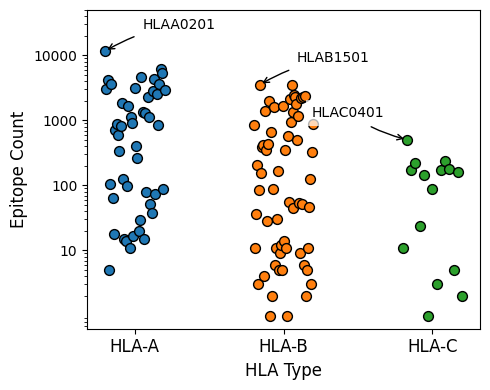

In [18]:
from matplotlib.ticker import FixedLocator, ScalarFormatter

plt.figure(figsize=(5, 4))

order = ["A", "B", "C"]

# Convert hla_type to a categorical with that specific order, then sort
hla_counts['hla_type'] = pd.Categorical(hla_counts['hla_type'], categories=order, ordered=True)
hla_counts = hla_counts.dropna(subset=['hla_type']).sort_values('hla_type')

# Prepare a mapping of color per HLA type
color_map = {
    'A': 'C0',
    'B': 'C1',
    'C': 'C2',
    # 'D': 'C3'
}

# Unique types in the specified order
unique_types = order
x_positions = np.arange(len(unique_types))

for i, hla in enumerate(unique_types):

    if 'D' in hla:
        continue

    subset = hla_counts[hla_counts['hla_type'] == hla]
    if subset.empty:
        continue
    
    # Spread points horizontally so they don't overlap
    n = len(subset)
    offsets = np.linspace(-0.2, 0.2, n)
    x_coords = x_positions[i] + offsets
    
    # Store the scatter points with their coordinates
    plt.scatter(
        x_coords,
        subset['Epitope Count'],
        edgecolor='black',
        linewidth=1.0,
        s=50
    )
    
    # Get the top point
    top1 = subset.nlargest(1, 'Epitope Count')
    
    for idx, row in top1.iterrows():
        # Find the corresponding x-coordinate from our scatter
        row_idx = subset.index.get_loc(idx)
        x_val = x_coords[row_idx]
        y_val = row['Epitope Count']
        
                # Flip label to left if it's HLA-C
        if hla == "C":
            xytext = (x_val - 0.15, y_val * 2)  # Left
            ha = 'right'
        else:
            xytext = (x_val + 0.25, y_val * 2)  # Right
            ha = 'left'

        plt.annotate(
            row['HLA'],
            xy=(x_val, y_val),
            xytext=xytext,
            arrowprops=dict(
                arrowstyle="->",
                connectionstyle="arc3,rad=0.1",
                linewidth=1.0
            ),
            fontsize=10,
            ha=ha,
            va='bottom',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
        )


# Set up log scale with specific y-ticks
ax = plt.gca()
ax.set_yscale('log')
ax.yaxis.set_major_locator(FixedLocator([10, 100, 1000, 10000, 100000]))  # Only these exact values
ax.yaxis.set_major_formatter(ScalarFormatter())  # Plain numbers
ax.set_ylim(-5, 50000)  # Adjusted limits to keep labels visible

# Customize x tick labels
x_labels = [f"HLA-{x}" for x in unique_types]
plt.xticks(x_positions, x_labels, size = 12)

plt.xlabel('HLA Type', size = 12)
plt.ylabel('Epitope Count', size = 12)

plt.tight_layout()
plt.savefig('../../figures_manuscript/1b_training_data_plot.pdf')
plt.show()


In [19]:
# def _norm_hla(h):
#     s = str(h).upper().replace(' ', '').replace('*', '').replace(':', '').replace('-', '')
#     return s if s.startswith('HLA') else 'HLA' + s

# # HLA -> set of eval epitopes
# eval_sets = (eval_epitopes_df
#              .assign(HLA_norm=lambda d: d['HLA'].map(_norm_hla),
#                      ep=lambda d: d['epitope'].astype(str).str.strip().str.upper())
#              .groupby('HLA_norm')['ep']
#              .apply(set))

# train_sets = (train_epitopes_df
#               .assign(HLA_norm=lambda d: d['HLA'].map(_norm_hla),
#                       ep=lambda d: d['epitope'].astype(str).str.strip().str.upper())
#               .groupby('HLA_norm')['ep']
#               .apply(set))
              
# # HLA -> set of sequences from plot_data
# plot_sets = (plot_data
#              .assign(HLA_norm=lambda d: d['level_0'].map(_norm_hla),
#                      ep=lambda d: d['sequence'].astype(str).str.strip().str.upper())
#              .groupby('HLA_norm')['ep']
#              .apply(set))

# common_hlas = eval_sets.index.intersection(plot_sets.index)

# rows = []
# overlap_long = []
# for h in common_hlas:
#     s_eval = eval_sets.loc[h]
#     s_plot = plot_sets.loc[h]
#     ov = s_eval & s_plot
#     rows.append({
#         'HLA': h,
#         'n_eval': len(s_eval),
#         'n_plot': len(s_plot),
#         'n_overlap': len(ov)
#     })
#     overlap_long.extend({'HLA': h, 'epitope': p} for p in ov)

# # summary per HLA
# overlap_summary = (pd.DataFrame(rows)
#                    .sort_values('n_overlap', ascending=False)
#                    .reset_index(drop=True))

# # one row per overlapping epitope
# overlap_epitopes_df = (pd.DataFrame(overlap_long)
#                        .sort_values(['HLA', 'epitope'])
#                        .reset_index(drop=True))


# # Use HLAs that appear in the plot data (so we only summarize HLAs we’re plotting)
# hlas = plot_sets.index

# rows = []
# overlap_eval_long  = []
# overlap_train_long = []

# for h in hlas:
#     s_plot  = plot_sets.loc[h] if h in plot_sets.index else set()
#     s_eval  = eval_sets.loc[h] if h in eval_sets.index else set()
#     s_train = train_sets.loc[h] if h in train_sets.index else set()

#     ov_eval  = s_plot & s_eval
#     ov_train = s_plot & s_train

#     # unions for Jaccard with each split
#     uni_eval  = s_plot | s_eval
#     uni_train = s_plot | s_train

#     rows.append({
#         'HLA': h,
#         'n_plot':  len(s_plot),
#         'n_eval':  len(s_eval),
#         'n_train': len(s_train),
#         'n_overlap_eval':  len(ov_eval),
#         'n_overlap_train': len(ov_train),
#         'jaccard_eval':  (len(ov_eval)  / len(uni_eval))  if len(uni_eval)  else np.nan,
#         'jaccard_train': (len(ov_train) / len(uni_train)) if len(uni_train) else np.nan,
#  })

#     overlap_eval_long.extend({'HLA': h, 'epitope': p, 'split': 'eval'}  for p in ov_eval)
#     overlap_train_long.extend({'HLA': h, 'epitope': p, 'split': 'train'} for p in ov_train)

# # Per-HLA summary including BOTH overlaps
# overlap_summary_both = (pd.DataFrame(rows)
#                         .sort_values(['n_overlap_eval','n_overlap_train','HLA'],
#                                      ascending=[False, False, True])
#                         .reset_index(drop=True))

# # Long form of actual overlapping epitopes, split-labeled
# overlap_epitopes_both_df = (pd.DataFrame(overlap_eval_long + overlap_train_long)
#                             .sort_values(['HLA','split','epitope'])
#                             .reset_index(drop=True))


In [20]:
plot_data = plot_data[~(plot_data['sequence'].isin(['YLVVVGAVGV', 'FPWDILFPS','QGFPWDILF']))]

In [ ]:
plot_data.to_csv('../../data/plot_SOTA.csv', index= False)

In [28]:
plot_data['level_0'] = plot_data['level_0'].str.replace('HLA','')

In [30]:
plot_data_subset = plot_data[plot_data['level_0'].isin(['A0101', 'A0201', 'A0205', 'A0301', 'A1101', 'A2402', 'A2601',
       'A3001', 'A3101', 'A3301', 'A6801', 'B0702', 'B0801', 'B1501',
       'B1801', 'B3801', 'B3901', 'B3906', 'B4402', 'B4403'])]

In [43]:
plot_data.groupby('level_0').size()

level_0
A0101    115
A0201    399
A0301    139
A1101     92
A2402    120
A2601      6
A3001      2
A3101      8
A3201      1
A6801     30
B0702    101
B0801     43
B1402      6
B1501      4
B1801     11
B3501      2
B3801     12
B3906      1
B4001      1
B4402     97
B4403      2
B5101      2
B5701      7
C0701      2
dtype: int64

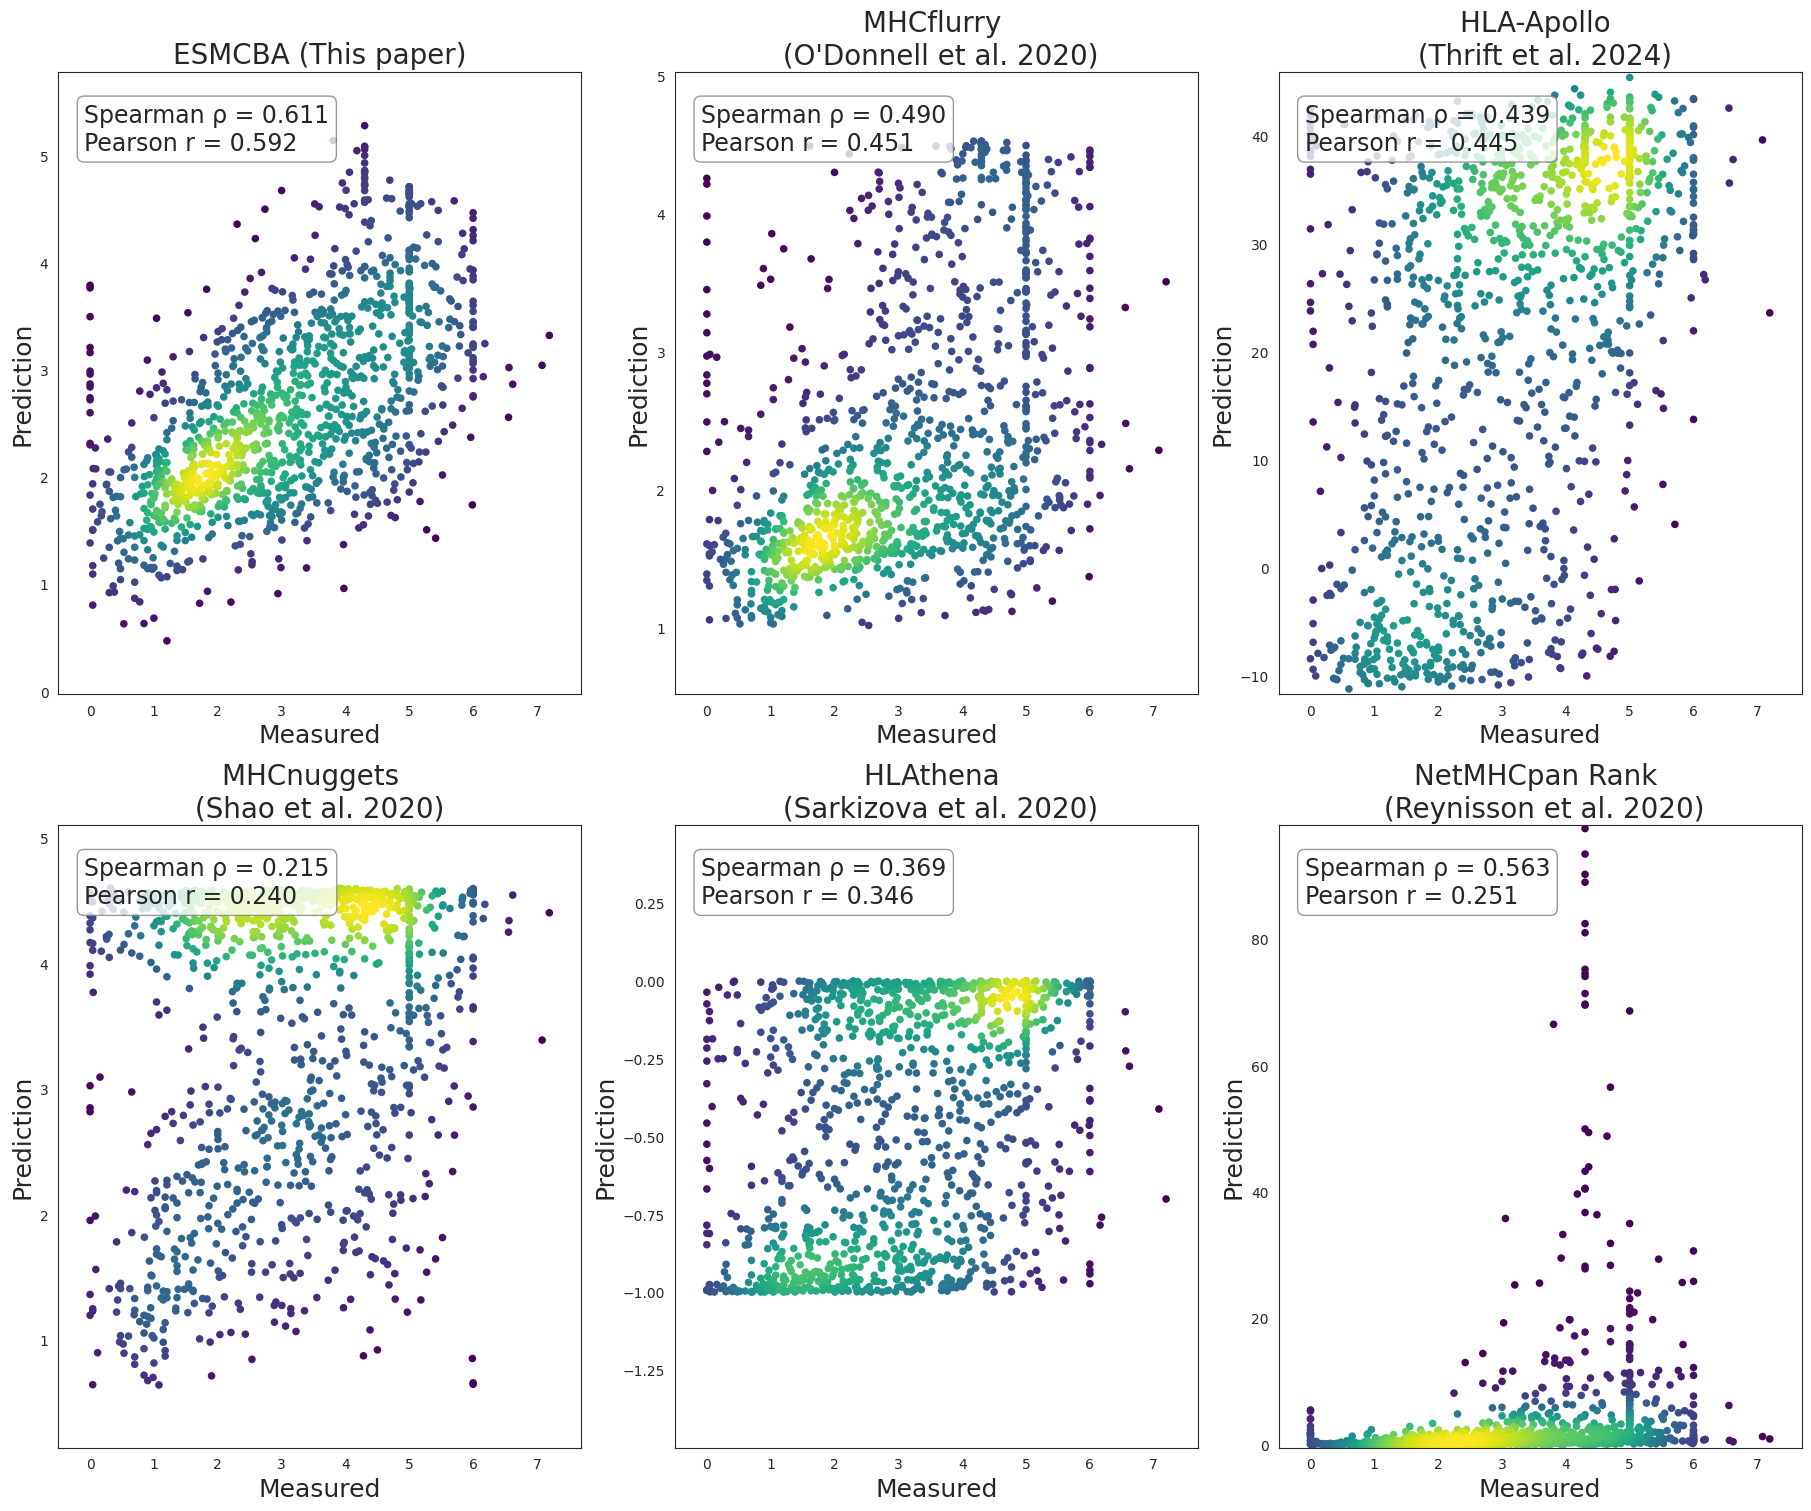

In [37]:
plot_pairs = [
    ('prediction', 'ESMCBA (This paper)'),
    ('mhc_log', "MHCflurry \n (O'Donnell et al. 2020)"),
    ('z_score_apollo', 'HLA-Apollo \n (Thrift et al. 2024)'),
    ('mhcnuggets_log', 'MHCnuggets  \n (Shao et al. 2020) '),
    ('best.MSi', 'HLAthena \n (Sarkizova et al. 2020)'),
    ('netmhc_log', 'NetMHCpan Rank \n (Reynisson et al. 2020)'),
    # ('mixmhc_rank', 'MixMHCpred (%Rank)'),
]


sns.set_style('white')

fig, axs = plt.subplots(2, 3, figsize=(18, 15), constrained_layout=True)
axs = axs.flatten()


for ax, (col, title) in zip(axs, plot_pairs):
    x = plot_data['measured']
    y = plot_data[col]

    # Drop NA
    valid = x.notna() & y.notna()
    x, y = x[valid], y[valid]

    # Density
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)
    idx = z.argsort()
    x, y, z = x.iloc[idx], y.iloc[idx], z[idx]

    # Plot
    sc = ax.scatter(x, y, c=z, cmap='viridis', s=30, edgecolor='none')
    spearman_rho, _ = spearmanr(x, y)
    pearson_r, _ = pearsonr(x, y)

    # Axis limits
    max_val = max(x.max(), y.max()) + 0.5
    ax.set_xlim(x.min()- 0.5, x.max() + 0.5)
    ax.set_ylim(y.min()- 0.5, y.max()+ 0.5)

    ax.set_title(title, fontsize=20)
    ax.set_xlabel('Measured', fontsize=18)
    ax.set_ylabel('Prediction', fontsize=18)
    
    # Correlation text with background box
    text_str = f'Spearman ρ = {spearman_rho:.3f}\nPearson r = {pearson_r:.3f}'
    ax.text(
        0.05, 0.95, text_str,
        transform=ax.transAxes,
        fontsize=17,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
    )

    for j in range(len(plot_pairs), len(axs)):
        axs[j].axis('off')

# from pathlib import Path
# out_dir = Path('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures_manuscript/')
# out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig("../../figures_manuscript/4a_SOTA_models.pdf", dpi=300, bbox_inches="tight")
# plt.close(fig)

plt.show()
